# workflow

In [2]:
import requests
import pandas as pd
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime, timedelta
import os
import json

In [ ]:
OPENWEATHER_API_KEY = ''
OPENAQ_API_KEY = ''

RADIUS_ROAD = 500
RADIUS_INDUSTRY = 5000
FARMLAND = 4000
DUMPSITE = 3000

DECAY_CONSTANT_ROAD = 200
DECAY_CONSTANT_INDUSTRY = 2000
DECAY_CONSTANT_FARMLAND = 1500
DECAY_CONSTANT_DUMPSITE = 1200

In [3]:
def get_air_quality_by_coords(lat, lon):
    headers = {"X-API-Key": OPENAQ_API_KEY}
    location_url = "https://api.openaq.org/v3/locations"
    params = {"coordinates": f"{lat},{lon}", "radius": 25000, "limit": 10}

    res = requests.get(location_url, headers=headers, params=params)
    if res.status_code != 200: return []

    locations = res.json().get("results", [])

    all_stations_data = []

    for location_data in locations:
        location_id = location_data["id"]
        latest_url = f"https://api.openaq.org/v3/locations/{location_id}/latest"
        latest_res = requests.get(latest_url, headers=headers)

        if latest_res.status_code != 200: continue

        results = latest_res.json().get("results", [])

        weather_url = f"https://api.openweathermap.org/data/2.5/weather"

        params = {
            "lat": location_data["coordinates"]["latitude"],
            "lon": location_data["coordinates"]["longitude"],
            "appid": OPENWEATHER_API_KEY,
            "units": "metric"
        }

        response = requests.get(weather_url, params=params)
        data = response.json()

        current_measurements = {
            "latitude": location_data["coordinates"]["latitude"],
            "longitude": location_data["coordinates"]["longitude"],
            "timestamp": None,
            "temperature_owm": data["main"]["temp"],
            "humidity_owm": data["main"]["humidity"],
            "wind_speed_owm": data["wind"]["speed"],
            "wind_direction_owm": data["wind"].get("deg", 0)
        }

        for item in results:
            if current_measurements["timestamp"] is None:
                dt = item.get("datetime")
                if dt:
                    current_measurements["timestamp"] = dt.get("utc")

            sensor_id = item.get("sensorsId")
            value = item.get("value")

            sensor_url = f"https://api.openaq.org/v3/sensors/{sensor_id}"
            sensor_res = requests.get(sensor_url, headers=headers)

            if sensor_res.status_code == 200:
                sensor_data = sensor_res.json().get("results", [])
                if sensor_data:
                    param = sensor_data[0].get("parameter", {}).get("name")
                    if param:
                        current_measurements[param] = value

        all_stations_data.append(current_measurements)

    return all_stations_data

In [4]:
x = get_air_quality_by_coords(19.0726, 72.8845)
print(len(x))
print(x)

5
[{'latitude': 19.1494, 'longitude': 72.9986, 'timestamp': '2020-04-09T00:15:00Z', 'temperature_owm': 34.03, 'humidity_owm': 25, 'wind_speed_owm': 6.55, 'wind_direction_owm': 307, 'so2': 32.69, 'pm10': 40.56, 'co': 1480.0, 'pm25': 20.4}, {'latitude': 19.192056, 'longitude': 72.9585188, 'timestamp': '2022-10-16T11:45:00Z', 'temperature_owm': 33.64, 'humidity_owm': 27, 'wind_speed_owm': 6.51, 'wind_direction_owm': 312, 'o3': 49.75, 'so2': 73.33, 'co': 10.0, 'pm25': 16.45, 'no2': 37.46, 'pm10': 72.15}, {'latitude': 18.91, 'longitude': 72.82, 'timestamp': '2022-10-31T01:45:00Z', 'temperature_owm': 28.38, 'humidity_owm': 60, 'wind_speed_owm': 6.93, 'wind_direction_owm': 312, 'so2': 16.77, 'co': 1.35, 'no2': 21.9, 'pm25': 27.45, 'o3': 11.42, 'pm10': 54.9, 'relativehumidity': 87.75, 'no': 27.3, 'temperature': 38.39, 'wind_speed': 4.08, 'nox': 0.0492, 'wind_direction': 232.85}, {'latitude': 19.1135051, 'longitude': 73.008978, 'timestamp': '2022-10-16T15:45:00Z', 'temperature_owm': 33.48, 'hum

In [5]:
def fetch_osm_features1(lat, lon):
    point = (lat, lon)

    road_tags = {"highway": True}
    try:
        roads = ox.features_from_point(point, tags=road_tags, dist=2000)
    except:
        roads = pd.DataFrame()

    industry_tags = {
        "landuse": "industrial",
        "building": "industrial",
        "man_made": ["works", "factory"]
    }
    try:
        industries = ox.features_from_point(point, tags=industry_tags, dist=5000)
    except:
        industries = pd.DataFrame()

    farm_tags = {
        "landuse": ["farmland", "farmyard", "orchard", "vineyard"],
        "agriculture": True
    }
    try:
        farmlands = ox.features_from_point(point, tags=farm_tags, dist=5000)
    except:
        farmlands = pd.DataFrame()

    waste_tags = {
        "landuse": "landfill",
        "amenity": "waste_disposal",
        "waste": ["disposal_site", "landfill"]
    }
    try:
        dumps = ox.features_from_point(point, tags=waste_tags, dist=5000)
    except:
        dumps = pd.DataFrame()

    return roads, industries, farmlands, dumps

In [6]:
from geopy.distance import geodesic

def calculate_feature_distances(sensor_lat, sensor_lon, gdf):
    distances = []
    if gdf is None or gdf.empty:
        return []

    for _, feature in gdf.iterrows():
        point = feature.geometry.centroid
        dist = geodesic(
            (sensor_lat, sensor_lon),
            (point.y, point.x)
        ).meters

        distances.append(dist)

    return distances

In [7]:
import numpy as np

def calculate_influence(distances, decay_constant):

    if len(distances) == 0:
        return 0

    distances = np.array(distances)

    influence = np.sum(
        np.exp(-distances / decay_constant)
    )

    return influence

In [8]:
import pandas as pd

def preprocess(df):
  print(df)
  df = pd.DataFrame(df)
  if 'timestamp' in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    df["hour"] = df["timestamp"].dt.hour
    df["day"] = df["timestamp"].dt.day
    df["month"] = df["timestamp"].dt.month

    df = df.fillna(df.mean())

  return df

In [9]:
def exp(lat, lon):
  pollution = get_air_quality_by_coords(lat, lon)
  influence_scores = []

  for i in pollution:
    print(i)
  for i in pollution:
    roads, industries, farmlands, dumps = fetch_osm_features1(i["latitude"], i["longitude"])
    road_dist  = calculate_feature_distances(i["latitude"], i["longitude"], roads)
    ind_dist   = calculate_feature_distances(i["latitude"], i["longitude"], industries)
    farm_dist  = calculate_feature_distances(i["latitude"], i["longitude"], farmlands)
    waste_dist = calculate_feature_distances(i["latitude"], i["longitude"], dumps)

    road_inf = calculate_influence(road_dist, DECAY_CONSTANT_ROAD)
    ind_inf = calculate_influence(ind_dist, DECAY_CONSTANT_INDUSTRY)
    farm_inf = calculate_influence(farm_dist, DECAY_CONSTANT_FARMLAND)
    dump_inf = calculate_influence(waste_dist, DECAY_CONSTANT_DUMPSITE)

    influence_scores.append(
        (road_inf, ind_inf, farm_inf, dump_inf)
    )

  for index, station_dict in enumerate(pollution):
    station_dict["road_influence"] = influence_scores[index][0]
    station_dict["industry_influence"] = influence_scores[index][1]
    station_dict["farm_influence"] = influence_scores[index][2]
    station_dict["dumpsite_influence"] = influence_scores[index][3]

  df = pd.DataFrame(pollution)
  print("Data curation complete")

  return df

In [ ]:
if __name__ == "__main__":

  locations_to_sample = [
    (20.2961, 85.8245), # Bhubaneswar
    (20.4625, 85.8830), # Cuttack
    (19.0760, 72.8777), # Mumbai
    (28.6139, 77.2090), # Delhi
    (22.5726, 88.3639), # Kolkata
    (22.8046, 86.2029), # Jamshedpur, Jharkhand
    (23.5204, 87.3119), # Durgapur, West Bengal
    (20.8444, 85.1511), # Angul, Odisha
    (22.3595, 82.7501), # Korba, Chhattisgarh
    (20.3711, 72.9106), # Vapi, Gujarat
    (28.6468, 77.3159) # Delhi (Anand Vihar)
  # (19.0726, 72.8845), # Mumbai (Kurla)
  # (22.5822, 88.3242), # Kolkata (Howrah)
  # (13.0285, 77.5195), # Bengaluru (Peenya)
  # (13.1667, 80.2667), # Chennai (Manali)
  # (30.9010, 75.8573), # Ludhiana, Punjab
  # (29.6857, 76.9907), # Karnal, Haryana
  # (26.1209, 85.3647), # Muzaffarpur, Bihar
  # (17.6868, 83.2185), # Visakhapatnam, AP
  # (22.0667, 88.0667) # Haldia, West Bengal
  ]
  final_dfs = []

  for lat, lon in locations_to_sample:
    print(f"Sampling around {lat}, {lon}...")
    temp_df = exp(lat, lon)
    final_dfs.append(temp_df)

  master_df = pd.concat(final_dfs, ignore_index=True)
  master_df.to_csv("master_dataset.csv", index=False)
  print("Master dataset complete!")

# complete csv

In [10]:
import sys
print(sys.executable)

c:\Users\karti\AppData\Local\Programs\Python\Python310\python.exe


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    FunctionTransformer,
    LabelEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression, LinearRegression, LogisticRegressionCV
from sklearn.metrics import classification_report,mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from scipy.stats import skew
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [2]:
df1 = pd.read_csv('enviro1.csv')
df2 = pd.read_csv('enviro2.csv')
df3 = pd.read_csv('enviro3.csv')
df4 = pd.read_csv('enviro4.csv')
df5 = pd.read_csv('enviro5.csv')
df6 = pd.read_csv('enviro6.csv')
df7 = pd.read_csv('enviro7.csv')
df8 = pd.read_csv('enviro8.csv')
df_final = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8])

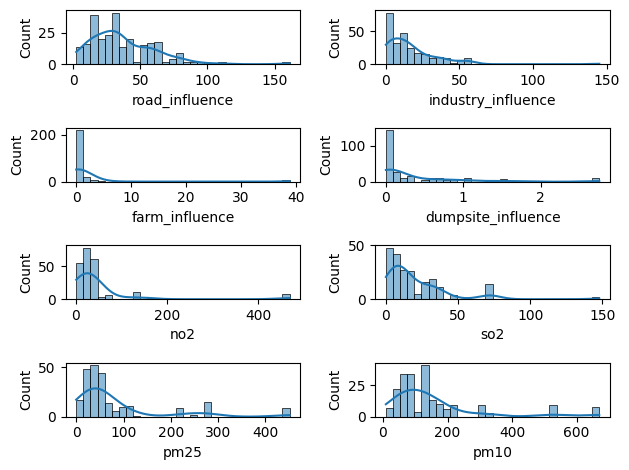

In [3]:
fig, ax = plt.subplots(4,2)
sns.histplot(df_final["road_influence"], bins=30, kde=True, ax = ax[0,0])
sns.histplot(df_final["industry_influence"], bins=30, kde=True, ax = ax[0,1])
sns.histplot(df_final["farm_influence"], bins=30, kde=True, ax = ax[1,0])
sns.histplot(df_final["dumpsite_influence"], bins=30, kde=True, ax = ax[1,1])
sns.histplot(df_final["no2"], bins=30, kde=True, ax = ax[2,0])
sns.histplot(df_final["so2"], bins=30, kde=True, ax = ax[2,1])
sns.histplot(df_final["pm25"], bins=30, kde=True, ax = ax[3,0])
sns.histplot(df_final["pm10"], bins=30, kde=True, ax = ax[3,1])
plt.tight_layout()
plt.show()

In [4]:
print(df_final.columns)
print("final shape: ",df_final.shape)

Index(['latitude', 'longitude', 'timestamp', 'temperature_owm', 'humidity_owm',
       'wind_speed_owm', 'wind_direction_owm', 'relativehumidity', 'pm10',
       'o3', 'no', 'no2', 'so2', 'temperature', 'co', 'pm25', 'wind_direction',
       'wind_speed', 'nox', 'road_influence', 'industry_influence',
       'farm_influence', 'dumpsite_influence', 'hour', 'day', 'month'],
      dtype='object')
final shape:  (264, 26)


In [5]:
df_final_removed = df_final.drop(['timestamp', 'hour', 'day', 'month'], axis = 1)
df_final_removed.columns

Index(['latitude', 'longitude', 'temperature_owm', 'humidity_owm',
       'wind_speed_owm', 'wind_direction_owm', 'relativehumidity', 'pm10',
       'o3', 'no', 'no2', 'so2', 'temperature', 'co', 'pm25', 'wind_direction',
       'wind_speed', 'nox', 'road_influence', 'industry_influence',
       'farm_influence', 'dumpsite_influence'],
      dtype='object')

In [6]:
df_final_removed = df_final_removed.drop_duplicates().copy()
print(df_final_removed.shape)
df_final_removed.info()

(256, 22)
<class 'pandas.core.frame.DataFrame'>
Index: 256 entries, 0 to 38
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   latitude            256 non-null    float64
 1   longitude           256 non-null    float64
 2   temperature_owm     256 non-null    float64
 3   humidity_owm        256 non-null    int64  
 4   wind_speed_owm      256 non-null    float64
 5   wind_direction_owm  256 non-null    int64  
 6   relativehumidity    140 non-null    float64
 7   pm10                201 non-null    float64
 8   o3                  191 non-null    float64
 9   no                  142 non-null    float64
 10  no2                 216 non-null    float64
 11  so2                 206 non-null    float64
 12  temperature         142 non-null    float64
 13  co                  206 non-null    float64
 14  pm25                230 non-null    float64
 15  wind_direction      115 non-null    float64
 16  wind

In [7]:
df_final_removed1 = df_final.drop(['temperature', 'wind_direction', 'wind_speed', 'relativehumidity', 'timestamp', 'hour', 'day', 'month'], axis = 1)
df_final_removed1.columns

Index(['latitude', 'longitude', 'temperature_owm', 'humidity_owm',
       'wind_speed_owm', 'wind_direction_owm', 'pm10', 'o3', 'no', 'no2',
       'so2', 'co', 'pm25', 'nox', 'road_influence', 'industry_influence',
       'farm_influence', 'dumpsite_influence'],
      dtype='object')

In [8]:
df_final_removed1 = df_final_removed1.drop_duplicates().copy()
print(df_final_removed1.shape)
df_final_removed1.info()

(256, 18)
<class 'pandas.core.frame.DataFrame'>
Index: 256 entries, 0 to 38
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   latitude            256 non-null    float64
 1   longitude           256 non-null    float64
 2   temperature_owm     256 non-null    float64
 3   humidity_owm        256 non-null    int64  
 4   wind_speed_owm      256 non-null    float64
 5   wind_direction_owm  256 non-null    int64  
 6   pm10                201 non-null    float64
 7   o3                  191 non-null    float64
 8   no                  142 non-null    float64
 9   no2                 216 non-null    float64
 10  so2                 206 non-null    float64
 11  co                  206 non-null    float64
 12  pm25                230 non-null    float64
 13  nox                 124 non-null    float64
 14  road_influence      256 non-null    float64
 15  industry_influence  256 non-null    float64
 16  farm

In [9]:
def assign_source_labels(df):
    def get_label(row):

        pm_ratio = row['pm25'] / (row['pm10'] + 1)
        if row['road_influence'] > 60 and row['no2'] > 30:
            return 0 #'Vehicular'
        elif row['industry_influence'] > 40 and row['so2'] > 15:
            return 1 #'Industrial'
        elif row['farm_influence'] > 10 and pm_ratio > 0.6:
            return 2 #'Agricultural'
        elif row['dumpsite_influence'] > 1.0 or (row['co'] > 1.2 and pm_ratio > 0.7):
            return 3 #'Burning'
        else:
            return 4 #'Natural' 

    df['Pollution Source encoded'] = df.apply(get_label, axis=1)
    return df
df_final = assign_source_labels(df_final_removed1)
df_final.to_csv("df_final.csv", index=False)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 256 entries, 0 to 38
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   latitude                  256 non-null    float64
 1   longitude                 256 non-null    float64
 2   temperature_owm           256 non-null    float64
 3   humidity_owm              256 non-null    int64  
 4   wind_speed_owm            256 non-null    float64
 5   wind_direction_owm        256 non-null    int64  
 6   pm10                      201 non-null    float64
 7   o3                        191 non-null    float64
 8   no                        142 non-null    float64
 9   no2                       216 non-null    float64
 10  so2                       206 non-null    float64
 11  co                        206 non-null    float64
 12  pm25                      230 non-null    float64
 13  nox                       124 non-null    float64
 14  road_influence  

In [14]:
def log_transform(x):
  x = x.copy()
  for column in range(x.shape[1]):
    if abs(skew(x[:,column])) > 1:
      x[:,column] = np.log1p(x[:,column])
  return x
log_transformer = FunctionTransformer(log_transform)

# model training

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    FunctionTransformer,
    LabelEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression, LinearRegression, LogisticRegressionCV
from sklearn.metrics import classification_report,mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from scipy.stats import skew
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [7]:
def log_transform(x):
  x = x.copy()
  for column in range(x.shape[1]):
    if abs(skew(x[:,column])) > 1:
      x[:,column] = np.log1p(x[:,column])
  return x
log_transformer = FunctionTransformer(log_transform)

In [8]:
df_final = pd.read_csv('df_final.csv')

In [15]:
model1 = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("log_transform", log_transformer),
        ("scaler", StandardScaler()),
        ('random forest model', RandomForestClassifier(
            n_estimators=100,     
            max_depth=3,        
            criterion='gini', 
            random_state=39,
            n_jobs=-1  
        ))
    ]
)

In [16]:
model2 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log_transform", log_transformer),
        ("scaler", StandardScaler()),
        ("decision_tree_model", DecisionTreeClassifier(
            max_depth=3,
            criterion="gini",
            random_state=39
        ))
    ]
)

In [17]:
model3 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log_transform", log_transformer),
        ("scaler", StandardScaler()),
        ("gradient_boosting_model", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=39
        ))
    ]
)

In [18]:
model4 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log_transform", log_transformer),
        ("scaler", StandardScaler()),
        ("xgboost_model", XGBClassifier(
            n_estimators=10,
            max_depth=3,
            learning_rate=0.1,
            random_state=39,
            n_jobs=-1,
            use_label_encoder=False,
            eval_metric="logloss",
            verbosity = 0
        ))
    ]
)

In [19]:
x = df_final.drop('Pollution Source encoded', axis = 1)
y = df_final['Pollution Source encoded']

In [20]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y, test_size = 0.2, random_state = 40)
model1.fit(xtrain, ytrain)
model2.fit(xtrain, ytrain)
model3.fit(xtrain, ytrain)
label_enc = LabelEncoder()
ytrain4 = label_enc.fit_transform(ytrain)
ytest4 = label_enc.transform(ytest)
model4.fit(xtrain, ytrain4)

,steps,"[('imputer', ...), ('log_transform', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,func,<function log...001ACDAFD9CF0>


In [21]:
print('Predictions on test set using the model1.')
predictions1 = model1.predict(xtest)
print(accuracy_score(ytest, predictions1),'\n',classification_report(ytest, predictions1),'\n',confusion_matrix(ytest, predictions1))
print('Predictions on test set using the model2.')
predictions2 = model2.predict(xtest)
print(accuracy_score(ytest, predictions2),'\n',classification_report(ytest, predictions2),'\n',confusion_matrix(ytest, predictions2))
print('Predictions on test set using the model3.')
predictions3 = model3.predict(xtest)
print(accuracy_score(ytest, predictions3),'\n',classification_report(ytest, predictions3),'\n',confusion_matrix(ytest, predictions3))
print('Predictions on test set using the model4.')
predictions4 = model4.predict(xtest)
print(accuracy_score(ytest4, predictions4),'\n',classification_report(ytest4, predictions4),'\n',confusion_matrix(ytest4, predictions4))

Predictions on test set using the model1.
0.9038461538461539 
               precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       1.00      0.50      0.67         4
           3       0.80      0.80      0.80         5
           4       0.90      1.00      0.95        38

    accuracy                           0.90        52
   macro avg       0.93      0.73      0.79        52
weighted avg       0.91      0.90      0.89        52
 
 [[ 3  0  0  2]
 [ 0  2  1  1]
 [ 0  0  4  1]
 [ 0  0  0 38]]
Predictions on test set using the model2.
0.8846153846153846 
               precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       1.00      0.50      0.67         4
           3       0.80      0.80      0.80         5
           4       0.88      1.00      0.94        38

    accuracy                           0.88        52
   macro avg       0.92      0.68      0.74       

c:\Users\karti\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\karti\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\karti\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [22]:
print('Predictions on train set using the model1.')
predictions1 = model1.predict(xtrain)
print(accuracy_score(ytrain, predictions1),'\n',classification_report(ytrain, predictions1),'\n',confusion_matrix(ytrain, predictions1))
print('Predictions on train set using the model2.')
predictions2 = model2.predict(xtrain)
print(accuracy_score(ytrain, predictions2),'\n',classification_report(ytrain, predictions2),'\n',confusion_matrix(ytrain, predictions2))
print('Predictions on train set using the model3.')
predictions3 = model3.predict(xtrain)
print(accuracy_score(ytrain, predictions3),'\n',classification_report(ytrain, predictions3),'\n',confusion_matrix(ytrain, predictions3))
print('Predictions on train set using the model4.')
predictions4 = model4.predict(xtrain)
print(accuracy_score(ytrain4, predictions4),'\n',classification_report(ytrain4, predictions4),'\n',confusion_matrix(ytrain4, predictions4))

Predictions on train set using the model1.
0.9509803921568627 
               precision    recall  f1-score   support

           0       1.00      0.79      0.88        14
           1       1.00      0.50      0.67        12
           3       1.00      0.96      0.98        24
           4       0.94      1.00      0.97       154

    accuracy                           0.95       204
   macro avg       0.98      0.81      0.87       204
weighted avg       0.95      0.95      0.95       204
 
 [[ 11   0   0   3]
 [  0   6   0   6]
 [  0   0  23   1]
 [  0   0   0 154]]
Predictions on train set using the model2.
0.9411764705882353 
               precision    recall  f1-score   support

           0       1.00      0.57      0.73        14
           1       1.00      0.50      0.67        12
           3       1.00      1.00      1.00        24
           4       0.93      1.00      0.96       154

    accuracy                           0.94       204
   macro avg       0.98      0.7

# cross validation and hyperparameter tuning

In [30]:
from sklearn.model_selection import cross_val_score, GridSearchCV
import joblib

Cross validation

In [25]:
scores_acc = cross_val_score(model1, xtrain, ytrain, cv=5, scoring='accuracy')
scores_f1 = cross_val_score(model1, xtrain, ytrain, cv=5, scoring='f1_weighted')

print("Accuracy scores model 1:", scores_acc)
print("Mean Accuracy model 1:", scores_acc.mean())

print("F1-weighted scores model 1:", scores_f1)
print("Mean F1-weighted model 1:", scores_f1.mean())

Accuracy scores model 1: [0.85365854 0.97560976 0.97560976 0.92682927 0.825     ]
Mean Accuracy model 1: 0.9113414634146342
F1-weighted scores model 1: [0.80784997 0.97173829 0.97336431 0.91502129 0.76304348]
Mean F1-weighted model 1: 0.8862034668940039


In [26]:
scores_acc = cross_val_score(model2, xtrain, ytrain, cv=5, scoring='accuracy')
scores_f1 = cross_val_score(model2, xtrain, ytrain, cv=5, scoring='f1_weighted')

print("Accuracy scores model 1:", scores_acc)
print("Mean Accuracy model 1:", scores_acc.mean())

print("F1-weighted scores model 1:", scores_f1)
print("Mean F1-weighted model 1:", scores_f1.mean())

Accuracy scores model 1: [0.95121951 0.75609756 0.90243902 0.87804878 0.875     ]
Mean Accuracy model 1: 0.8725609756097562
F1-weighted scores model 1: [0.93978659 0.79336043 0.91300813 0.88368377 0.81716418]
Mean F1-weighted model 1: 0.8694006192056258


In [27]:
scores_acc = cross_val_score(model3, xtrain, ytrain, cv=5, scoring='accuracy')
scores_f1 = cross_val_score(model3, xtrain, ytrain, cv=5, scoring='f1_weighted')

print("Accuracy scores model 1:", scores_acc)
print("Mean Accuracy model 1:", scores_acc.mean())

print("F1-weighted scores model 1:", scores_f1)
print("Mean F1-weighted model 1:", scores_f1.mean())

Accuracy scores model 1: [0.80487805 0.80487805 0.58536585 0.90243902 0.25      ]
Mean Accuracy model 1: 0.6695121951219513
F1-weighted scores model 1: [0.82804878 0.8461737  0.6515904  0.91159705 0.28014706]
Mean F1-weighted model 1: 0.7035113977571934


In [28]:
scores_acc = cross_val_score(model4, xtrain, ytrain4, cv=5, scoring='accuracy')
scores_f1 = cross_val_score(model4, xtrain, ytrain4, cv=5, scoring='f1_weighted')

print("Accuracy scores model 1:", scores_acc)
print("Mean Accuracy model 1:", scores_acc.mean())

print("F1-weighted scores model 1:", scores_f1)
print("Mean F1-weighted model 1:", scores_f1.mean())

Accuracy scores model 1: [0.70731707 0.87804878 0.90243902 0.82926829 0.825     ]
Mean Accuracy model 1: 0.8284146341463414
F1-weighted scores model 1: [0.64301552 0.85936895 0.86881005 0.83378347 0.76304348]
Mean F1-weighted model 1: 0.7936042950644745


Hyperparameter tuning

In [32]:
param1 = {
    'random forest model__n_estimators' : [50, 100, 150],
    'random forest model__max_depth': [3, 5, 10]
}
param2 = {
    'decision_tree_model__max_depth': [2, 3, 5],
    'decision_tree_model__max_features': ['sqrt', 'log2', None]
}
param3 = {
    'gradient_boosting_model__n_estimators': [20, 50, 100],
    'gradient_boosting_model__learning_rate': [0.01, 0.1],
    'gradient_boosting_model__max_depth': [1, 3, 5]
}
param4 = {
    'xgboost_model__max_iter': [5, 10, 15],
    'xgboost_model__learning_rate': [0.01, 0.1],
    'xgboost_model__max_depth': [2, 3, 5]
}

In [33]:
grid_search1 = GridSearchCV(
    estimator=model1, param_grid=param1, 
    cv=5, scoring={'acc': 'accuracy', 'f1': 'f1_weighted'}, 
    refit='f1',n_jobs=-1)
grid_search1.fit(xtrain, ytrain)
print(f"Best Params (via Accuracy): {grid_search1.best_params_}")
print(f"Best Accuracy Score: {grid_search1.best_score_:.4f}")

Best Params (via Accuracy): {'random forest model__max_depth': 10, 'random forest model__n_estimators': 100}
Best Accuracy Score: 0.9571


In [34]:
ypred10 = grid_search1.predict(xtest) 
print('Test predictions')
print(accuracy_score(ytest, ypred10), classification_report(ytest, ypred10), confusion_matrix(ytest, ypred10))
ypred11 = grid_search1.predict(xtrain) 
print('Train predictions')
print(accuracy_score(ytrain, ypred11), classification_report(ytrain, ypred11), confusion_matrix(ytrain, ypred11))

Test predictions
0.8846153846153846               precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       0.60      0.75      0.67         4
           3       0.80      0.80      0.80         5
           4       0.92      0.95      0.94        38

    accuracy                           0.88        52
   macro avg       0.83      0.77      0.79        52
weighted avg       0.89      0.88      0.88        52
 [[ 3  0  0  2]
 [ 0  3  1  0]
 [ 0  0  4  1]
 [ 0  2  0 36]]
Train predictions
1.0               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        12
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00       154

    accuracy                           1.00       204
   macro avg       1.00      1.00      1.00       204
weighted avg       1.00      1.00      1.00       204
 [[ 14   0  

In [35]:
grid_search2 = GridSearchCV(
    estimator=model2, param_grid=param2, 
    cv=5, scoring={'acc': 'accuracy', 'f1': 'f1_weighted'}, 
    refit='f1',n_jobs=-1)
grid_search2.fit(xtrain, ytrain)
print(f"Best Params (via Accuracy): {grid_search2.best_params_}")
print(f"Best Accuracy Score: {grid_search2.best_score_:.4f}")

Best Params (via Accuracy): {'decision_tree_model__max_depth': 3, 'decision_tree_model__max_features': None}
Best Accuracy Score: 0.8694


In [36]:
ypred10 = grid_search2.predict(xtest) 
print('Test predictions')
print(accuracy_score(ytest, ypred10), classification_report(ytest, ypred10), confusion_matrix(ytest, ypred10))
ypred11 = grid_search2.predict(xtrain) 
print('Train predictions')
print(accuracy_score(ytrain, ypred11), classification_report(ytrain, ypred11), confusion_matrix(ytrain, ypred11))

Test predictions
0.8846153846153846               precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       1.00      0.50      0.67         4
           3       0.80      0.80      0.80         5
           4       0.88      1.00      0.94        38

    accuracy                           0.88        52
   macro avg       0.92      0.68      0.74        52
weighted avg       0.90      0.88      0.87        52
 [[ 2  0  0  3]
 [ 0  2  1  1]
 [ 0  0  4  1]
 [ 0  0  0 38]]
Train predictions
0.9411764705882353               precision    recall  f1-score   support

           0       1.00      0.57      0.73        14
           1       1.00      0.50      0.67        12
           3       1.00      1.00      1.00        24
           4       0.93      1.00      0.96       154

    accuracy                           0.94       204
   macro avg       0.98      0.77      0.84       204
weighted avg       0.95      0.94      0.93       2

In [37]:
grid_search3 = GridSearchCV(
    estimator=model3, param_grid=param3, 
    cv=5, scoring={'acc': 'accuracy', 'f1': 'f1_weighted'}, 
    refit='f1',n_jobs=-1)
grid_search3.fit(xtrain, ytrain)
print(f"Best Params (via Accuracy): {grid_search3.best_params_}")
print(f"Best Accuracy Score: {grid_search3.best_score_:.4f}")

Best Params (via Accuracy): {'gradient_boosting_model__learning_rate': 0.1, 'gradient_boosting_model__max_depth': 1, 'gradient_boosting_model__n_estimators': 20}
Best Accuracy Score: 0.7837


In [38]:
ypred10 = grid_search3.predict(xtest) 
print('Test predictions')
print(accuracy_score(ytest, ypred10), classification_report(ytest, ypred10), confusion_matrix(ytest, ypred10))
ypred11 = grid_search3.predict(xtrain) 
print('Train predictions')
print(accuracy_score(ytrain, ypred11), classification_report(ytrain, ypred11), confusion_matrix(ytrain, ypred11))

Test predictions
0.9423076923076923               precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       1.00      1.00      1.00         4
           3       1.00      0.80      0.89         5
           4       0.93      1.00      0.96        38

    accuracy                           0.94        52
   macro avg       0.98      0.85      0.90        52
weighted avg       0.95      0.94      0.94        52
 [[ 3  0  0  2]
 [ 0  4  0  0]
 [ 0  0  4  1]
 [ 0  0  0 38]]
Train predictions
0.9558823529411765               precision    recall  f1-score   support

           0       1.00      0.86      0.92        14
           1       0.73      0.67      0.70        12
           3       1.00      0.96      0.98        24
           4       0.96      0.99      0.97       154

    accuracy                           0.96       204
   macro avg       0.92      0.87      0.89       204
weighted avg       0.96      0.96      0.95       2

In [39]:
grid_search4 = GridSearchCV(
    estimator=model4, param_grid=param4, 
    cv=5, scoring={'acc': 'accuracy', 'f1': 'f1_weighted'}, 
    refit='f1',n_jobs=-1)
grid_search4.fit(xtrain, ytrain4)
print(f"Best Params (via Accuracy): {grid_search3.best_params_}")
print(f"Best Accuracy Score: {grid_search3.best_score_:.4f}")

Best Params (via Accuracy): {'gradient_boosting_model__learning_rate': 0.1, 'gradient_boosting_model__max_depth': 1, 'gradient_boosting_model__n_estimators': 20}
Best Accuracy Score: 0.7837


In [40]:
ypred10 = grid_search4.predict(xtest) 
print('Test predictions')
print(accuracy_score(ytest4, ypred10), classification_report(ytest4, ypred10), confusion_matrix(ytest4, ypred10))
ypred11 = grid_search4.predict(xtrain) 
print('Train predictions')
print(accuracy_score(ytrain4, ypred11), classification_report(ytrain4, ypred11), confusion_matrix(ytrain4, ypred11))

Test predictions
0.8846153846153846               precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       1.00      0.25      0.40         4
           2       0.80      0.80      0.80         5
           3       0.88      1.00      0.94        38

    accuracy                           0.88        52
   macro avg       0.92      0.66      0.72        52
weighted avg       0.90      0.88      0.87        52
 [[ 3  0  0  2]
 [ 0  1  1  2]
 [ 0  0  4  1]
 [ 0  0  0 38]]
Train predictions
0.9852941176470589               precision    recall  f1-score   support

           0       1.00      0.86      0.92        14
           1       1.00      1.00      1.00        12
           2       1.00      0.96      0.98        24
           3       0.98      1.00      0.99       154

    accuracy                           0.99       204
   macro avg       1.00      0.95      0.97       204
weighted avg       0.99      0.99      0.98       2

In [44]:
joblib.dump(grid_search3, 'decision_tree_model.pkl')
joblib.dump(model1, 'random_forest_model.pkl')

['random_forest_model.pkl']

# ui

In [1]:
import geopandas as gpd
import joblib
from util import log_transform, output_pollution_source
from sklearn.model_selection import train_test_split
import pandas as pd
import folium
from folium.plugins import HeatMap, MarkerCluster

In [3]:
df = pd.read_csv('df_final.csv')
x = df.drop('Pollution Source encoded', axis = 1)
y = df['Pollution Source encoded']

In [4]:
model = joblib.load('decision_tree_model.pkl')
predictions = model.predict(x)

In [33]:
import numpy as np
var = 'road_influence'
print(np.min(x[var]))
print(np.max(x[var]))
print(x[var].dtype)
var = 'industry_influence'
print(np.min(x[var]))
print(np.max(x[var]))
print(x[var].dtype)


2.243981448976691
161.10903019807645
float64
0.0
144.95480470430445
float64


In [14]:
print(model.feature_names_in_)

['latitude' 'longitude' 'temperature_owm' 'humidity_owm' 'wind_speed_owm'
 'wind_direction_owm' 'pm10' 'o3' 'no' 'no2' 'so2' 'co' 'pm25' 'nox'
 'road_influence' 'industry_influence' 'farm_influence'
 'dumpsite_influence']


In [26]:
# print(predictions)
prediction_labels = output_pollution_source(predictions)
x['predicted_labels'] = prediction_labels
# print(x)

In [20]:
gdf = gpd.GeoDataFrame(x, geometry=gpd.points_from_xy(x.longitude, x.latitude), crs="EPSG:4324")

In [38]:
import folium
from folium.plugins import HeatMap, MarkerCluster

x = x.dropna(subset=['pm25', 'latitude', 'longitude'])
m = folium.Map(location=[x.latitude.mean(), x.longitude.mean()], zoom_start=5, tiles='CartoDB positron')

heat_data = x[['latitude', 'longitude', 'pm25']].values.tolist()
HeatMap(heat_data, radius=15, blur=20, name="Pollution Heatmap").add_to(m)

source_layers = {}
for source_type in x['predicted_labels'].unique():
    source_layers[source_type] = folium.FeatureGroup(name=f"Source: {source_type}")

icon_map = {
    'industrial': {'icon': 'industry', 'color': 'darkred'},
    'vehicular': {'icon': 'car', 'color': 'blue'},
    'agricultural': {'icon': 'leaf', 'color': 'green'},
    'burning': {'icon': 'fire', 'color': 'orange'},
    'natural': {'icon': 'tree', 'color': 'lightgreen'}
}

for idx, row in x.iterrows():
    style = icon_map.get(row['predicted_labels'].lower(), {'icon': 'info-sign', 'color': 'gray'})
    
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        icon=folium.Icon(color=style['color'], icon=style['icon'], prefix='fa'),
        popup=f"<b>Source:</b> {row['predicted_labels']}<br><b>PM2.5:</b> {row['pm25']}"
    ).add_to(source_layers[row['predicted_labels']])

for layer in source_layers.values():
    layer.add_to(m)

folium.LayerControl().add_to(m)
m.save("pollution_map.html")